In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

# plot style
sns.set_context("notebook", font_scale=1.2)
sns.set_palette("muted")

plt.rcParams.update({
    "font.size": 15,
    "figure.dpi": 100,
    "grid.alpha": 0.3,
    "axes.grid": False,
    "axes.axisbelow": True,
    "figure.figsize": (8, 6),
    "mathtext.fontset": "cm",
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "axes.labelsize": 16,
    "legend.fontsize": 13.5,
    "text.usetex": False,
    "font.family": "serif",
})

In [5]:
SWEEP_NAME = "sweep_2026_06_24_2300"
DATA_DIR = Path("data") / SWEEP_NAME

sim_df = pd.read_feather(DATA_DIR / "simulations.arrow")

print("Simulations:", sim_df.shape)
print("Design points:", sim_df["design_id"].nunique())
print("Repetitions per design point:")
print(sim_df.groupby("design_id")["rep_id"].nunique().describe())

Simulations: (491520, 16)
Design points: 16384
Repetitions per design point:
count    16384.0
mean        30.0
std          0.0
min         30.0
25%         30.0
50%         30.0
75%         30.0
max         30.0
Name: rep_id, dtype: float64


### Verification Rate vs. Veracity Differential

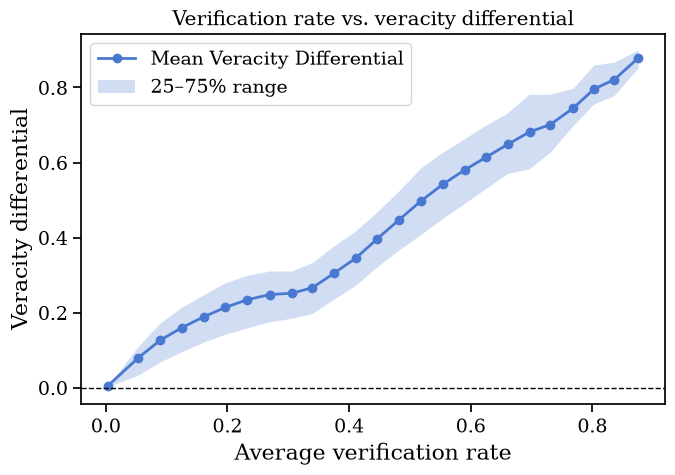

In [10]:
# bin verification rate and compute mean + quantile band
df = sim_df[["avg_verify_rate", "veracity_differential"]].dropna().copy()

df["verify_bin"] = pd.cut(df["avg_verify_rate"], bins=25)

binned = (
    df.groupby("verify_bin", observed=True)
      .agg(
          verify_mid=("avg_verify_rate", "mean"),
          vd_mean=("veracity_differential", "mean"),
          vd_q25=("veracity_differential", lambda x: x.quantile(0.25)),
          vd_q75=("veracity_differential", lambda x: x.quantile(0.75)),
      )
      .reset_index(drop=True)
)

plt.figure(figsize=(7, 5))

plt.plot(
    binned["verify_mid"],
    binned["vd_mean"],
    marker="o",
    linewidth=2,
    label="Mean Veracity Differential"
)

plt.fill_between(
    binned["verify_mid"],
    binned["vd_q25"],
    binned["vd_q75"],
    alpha=0.25,
    label="25–75% range"
)

plt.axhline(0, color="black", linewidth=1, linestyle="--")

plt.xlabel("Average verification rate")
plt.ylabel("Veracity differential")
plt.title("Verification rate vs. veracity differential")
plt.legend()

plt.tight_layout()
plt.show()

### True and Fake Cascade Sizes

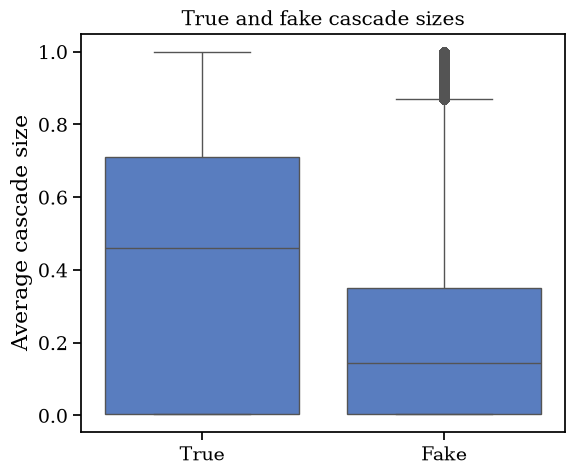

In [11]:
cascade_long = sim_df[["avg_true_cascade", "avg_fake_cascade"]].melt(
    var_name="Cascade type",
    value_name="Average cascade size"
)

cascade_long["Cascade type"] = cascade_long["Cascade type"].replace({
    "avg_true_cascade": "True",
    "avg_fake_cascade": "Fake"
})

plt.figure(figsize=(6, 5))

sns.boxplot(
    data=cascade_long,
    x="Cascade type",
    y="Average cascade size"
)

plt.xlabel("")
plt.ylabel("Average cascade size")
plt.title("True and fake cascade sizes")

plt.tight_layout()
plt.show()